# W States Tutorial

## Introduction to W States

The W state is a highly entangled quantum state of n qubits that represents a fundamentally different type of multi-partite entanglement compared to GHZ states. Named after its discovery in the context of three-qubit entanglement classification, the W state is particularly notable for its robustness to particle loss.

### Mathematical Representation

For n qubits, the W state is a symmetric superposition with exactly one excitation:

**|W_n⟩ = (|100...0⟩ + |010...0⟩ + |001...0⟩ + ... + |000...1⟩)/√n**

Examples:
- 3 qubits: **|W₃⟩ = (|100⟩ + |010⟩ + |001⟩)/√3**
- 4 qubits: **|W₄⟩ = (|1000⟩ + |0100⟩ + |0010⟩ + |0001⟩)/√4**
- 5 qubits: **|W₅⟩ = (|10000⟩ + |01000⟩ + ... + |00001⟩)/√5**

### Key Properties

1. **Symmetric Superposition**: Equal amplitude for all states with exactly one |1⟩
2. **Robustness to Particle Loss**: Unlike GHZ, survives loss of individual qubits
3. **Different Entanglement Class**: Cannot be converted to/from GHZ by local operations
4. **Lower Entanglement Entropy**: Compared to GHZ states
5. **Practical Resilience**: Better suited for imperfect quantum channels

### W State vs GHZ State: Key Differences

| Property | GHZ States | W States |
|----------|------------|----------|
| **Pattern** | All 0s or all 1s | Exactly one 1, rest 0s |
| **Outcomes** | 2 outcomes | n outcomes |
| **Particle Loss** | Complete failure | Survives with high probability |
| **Entanglement Type** | Maximal | High but different class |
| **Use Case** | Perfect channels | Robust communication |


This tutorial will guide you through creating, executing, and analyzing W states, with emphasis on their unique robustness properties.



## Setup & Authentication

We reuse the same authentication pattern as previous modules: load `API_KEY` from `qcloud.env` and authenticate with `QpiAIQuantumAuth`.

In [1]:
import os

from dotenv import load_dotenv
from qpiai_quantum import QpiAIQuantumAuth

load_dotenv("./qcloud.env") # This path should point to the env file containing your API key.

QpiAIQuantumAuth.login(os.getenv("API_KEY"))
user_info = QpiAIQuantumAuth.me()

print(f"✅ Authenticated successfully as: {user_info.get('name', 'User')} ({user_info.get('email', '')})")

✅ Authenticated successfully as: Test Advanced User (test_advanced@qpiai.tech)


## Part 1: Creating a Basic W State

Let's start by creating a 3-qubit W state to understand the circuit construction.

### Circuit Construction

The W state uses a recursive construction with controlled rotations:
1. **Controlled rotations** with specific angles to distribute the excitation
2. **CNOT gates** to create the symmetric superposition
3. Each qubit shares the single excitation equally

Note: W state circuits are more complex than GHZ circuits due to the controlled rotation requirements.

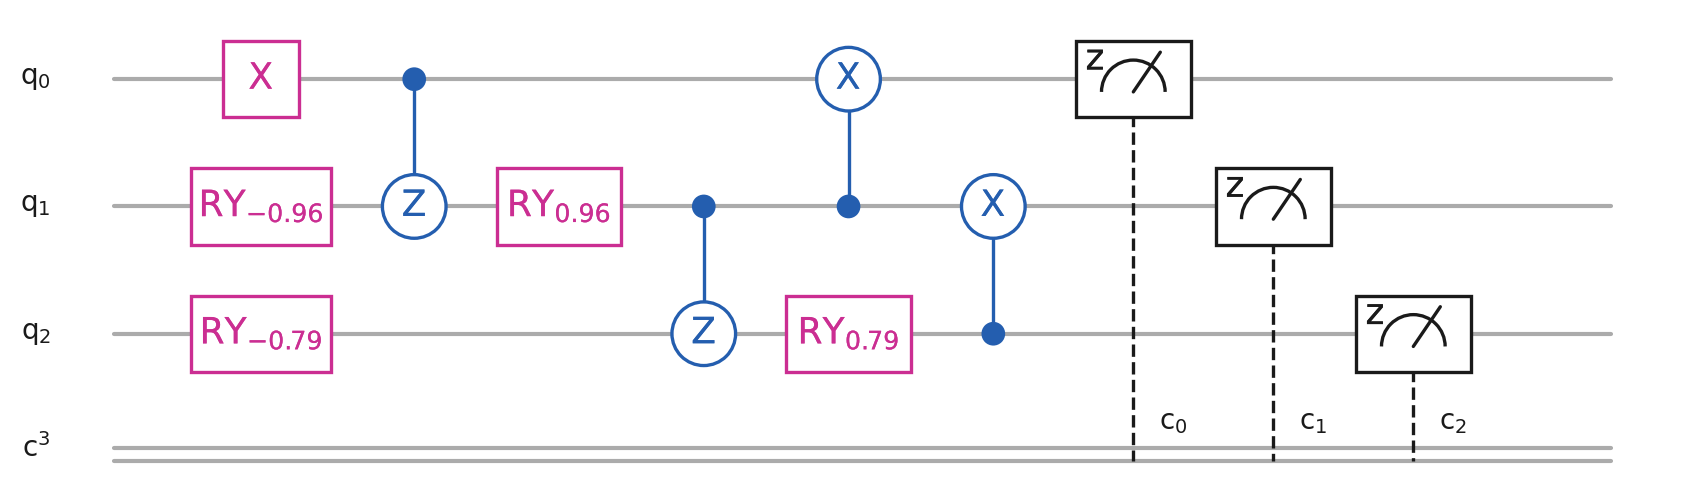

In [2]:
import numpy as np
from qpiai_quantum.state_preparation import WStateGenerator

w_state = WStateGenerator(num_qubits=3)
circuit = w_state.build_circuit()
circuit.show()

### Execute on QpiAI Quantum Hardware

Now we'll execute the circuit and analyze the results:

> **Note:** The `experiment_name` parameter is omitted here because it is only required for cloud executions (e.g., on QCloud simulators or Indus QPU). For local simulation (`QpiAI-QSV-Local`), it is not needed.


In [3]:
shots = 10000
# Note: experiment_name is only required for cloud executions
result = circuit.run(shots=shots, device_name="QpiAI-QSV-Local")
counts = result.get_counts()
print(f"Counts : {counts}")

Counts : {'001': 3359, '010': 3235, '100': 3406}


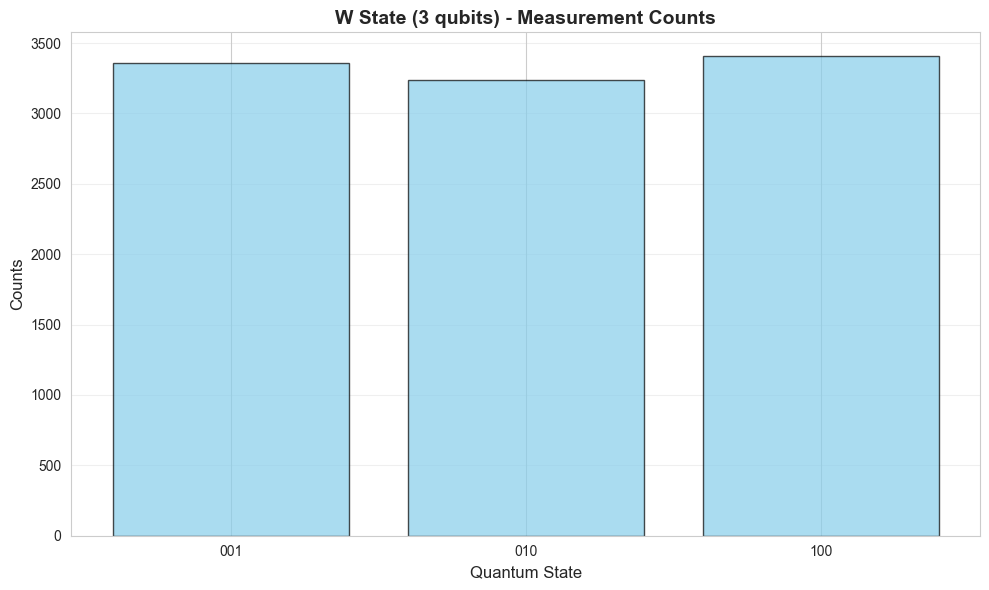

In [4]:
w_state.visualize('histogram', result=result)

### Analyze Expected Outcomes

In [5]:
expected = w_state.get_expected_outcomes()
print(f"Expected outcomes: {expected}")
print(f"\nNote: Each state has exactly one |1⟩ with probability 1/{w_state.num_qubits}")

Expected outcomes: {'100': 0.3333333333333333, '010': 0.3333333333333333, '001': 0.3333333333333333}

Note: Each state has exactly one |1⟩ with probability 1/3


## Summary and Key Takeaways

In this tutorial, we've comprehensively explored W states and their unique properties:

### What We Learned

1. **W State Fundamentals**: Symmetric superposition with exactly one excitation
2. **Circuit Construction**: Complex controlled rotations for equal distribution
3. **W vs GHZ Comparison**: Different entanglement classes with different strengths

### The Key Advantage: ROBUSTNESS

**Why W States Matter:**

| Loss Scenario | GHZ State | W State |
|---------------|-----------|---------|
| Lose 1 qubit | **0% survival** | **~67% survival** (3-qubit) |
| Lose 2 qubits | **0% survival** | **~44% survival** (3-qubit) |
| Use Case | Perfect lab conditions | Real-world networks |

### Critical Differences: W vs GHZ vs Bell

| Property | Bell | GHZ | W |
|----------|------|-----|---|
| **Qubits** | 2 | 3+ | 3 |
| **Outcomes** | 2 | 2 | n |
| **Pattern** | Same/opposite | All same | One different |
| **Entanglement** | Maximal | Maximal | High (different class) |

### Key Methods Reference

- `WStateGenerator(num_qubits)` - Create W state generator (min 3 qubits)
- `build_circuit(measure=True)` - Build quantum circuit with controlled rotations
- `run(shots, backend)` - Execute on quantum backend (Note: `experiment_name` is optional and only required for cloud executions)
- `get_expected_outcomes()` - Get theoretical distribution (1/n for each)


### When to Use W States

**Use W states when:**
- Working with imperfect quantum channels
- Building robust quantum networks
- Expecting potential qubit loss
- Need resilient quantum communication
- Distributed quantum computing with unreliable nodes

**Use GHZ states when:**
- Have perfect quantum control
- Need maximal entanglement for specific protocols
- Working in ideal lab conditions
- Require all-or-nothing correlations

---

**Thank you for learning with QpiAI!**

In [6]:
import qpiai_quantum
print(qpiai_quantum.__version__)

0.1.32
